In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy import stats

In [6]:
ft2 = pd.read_csv('cstlisten.csv')

In [8]:
ft2

,Week number,A(H1N1),A(H3N2),A(unknown),B,Influenza 2020-2021 (%),Influenza 2019-2020 (%),Temperature,Wind_speed,Surface_Pressure,NO,PM2.5,SO2,CO,Year,total_flu,total_A,relative_humidity,NO_SO2
0,23.0,0.0,0.0,0.0,1.0,6.260976,5.226923,11.946286,6.024857,100.493714,0.001473,9.729600,0.005577,506.718000,2015.0,1.0,0.0,76.634404,0.000008
1,40.0,0.0,3.0,5.0,6.0,6.260976,5.226923,11.740286,2.657714,102.480000,0.005648,11.686000,0.008509,427.469429,2015.0,14.0,8.0,82.017244,0.000048
2,41.0,6.0,2.0,21.0,2.0,6.260976,5.226923,12.106857,3.706857,100.503714,0.005648,11.686000,0.008509,751.117143,2015.0,31.0,29.0,90.151233,0.000048
3,42.0,7.0,0.0,6.0,5.0,6.260976,5.226923,9.672000,3.170000,101.436286,0.005648,11.686000,0.008509,462.478571,2015.0,18.0,13.0,84.163767,0.000048
4,43.0,6.0,1.0,5.0,4.0,6.260976,5.226923,10.287143,3.145143,101.372000,0.005648,11.686000,0.008509,577.775857,2015.0,16.0,12.0,89.044841,0.000048
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
367,25.0,0.0,18.0,25.0,6.0,6.260976,5.226923,13.256786,3.978214,99.964123,0.194743,6.124571,1.996857,173.231429,2024.0,49.0,43.0,84.514239,0.388874
368,26.0,1.0,16.0,16.0,0.0,6.260976,5.226923,16.717419,3.496461,100.455179,0.233429,4.631429,1.966571,190.740000,2024.0,33.0,33.0,84.442906,0.459054
369,27.0,3.0,13.0,12.0,6.0,6.260976,5.226923,13.947321,4.243409,100.288555,0.316657,5.722286,1.929714,234.791429,2024.0,34.0,28.0,83.120743,0.611058
370,28.0,0.0,29.0,18.0,4.0,6.260976,5.226923,14.340097,4.486705,99.996721,0.202571,6.187143,2.112286,203.965714,2024.0,51.0,47.0,87.238200,0.427889


In [16]:
ft2.columns

Index(['Week number', 'A(H1N1)', 'A(H3N2)', 'A(unknown)', 'B',
       'Influenza 2020-2021 (%)', 'Influenza 2019-2020 (%)', 'Temperature',
       'Wind_speed', 'Surface_Pressure', 'NO', 'PM2.5', 'SO2', 'CO', 'Year',
       'total_flu', 'total_A', 'relative_humidity', 'NO_SO2'],
      dtype='object')

# A(H1N1)

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ensure you have imported train_test_split
from sklearn.model_selection import train_test_split

# Features and target
features = ['Temperature', 'Wind_speed', 'Surface_Pressure', 'NO', 'PM2.5', 'SO2', 'CO', 'relative_humidity']
target = 'A(H1N1)'

# Step 1: Prepare the data
X = ft2[features].values  # Feature matrix
y = ft2[target].values  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", grid_search.best_params_)

# Best estimator
best_gbr = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_gbr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print(f"Best Gradient Boosting Regressor - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


In [62]:
import pandas as pd

# Assuming X_test is a NumPy array, you can convert it to a DataFrame with proper names:
features = ['Temperature', 'Wind_speed', 'Surface_Pressure', 'NO', 'PM2.5', 'SO2', 'CO', 'relative_humidity']
X_test = pd.DataFrame(X_test, columns=features)


In [70]:
X_test

,Temperature,Wind_speed,Surface_Pressure,NO,PM2.5,SO2,CO,relative_humidity
0,19.310286,3.021143,100.913714,1.151143,9.488571,2.324857,277.960000,78.697796
1,14.174000,3.311143,100.071429,0.002313,14.108000,0.006849,691.701143,83.073051
2,6.473429,6.134857,98.650857,0.007445,13.404000,0.007217,713.405143,98.262706
3,18.041714,2.907143,100.896571,0.264429,5.120857,1.348857,183.954286,76.947258
4,8.208286,5.619714,100.738000,0.001976,11.716000,0.004660,337.609714,92.037645
...,...,...,...,...,...,...,...,...
70,2.794000,4.634857,100.833143,0.003985,12.656000,0.005355,453.110714,83.736798
71,4.582000,2.492571,102.542000,0.797657,8.524000,2.641714,213.525714,91.378698
72,12.747143,3.408857,101.811714,0.254743,6.275714,1.366286,197.314286,77.029470
73,7.603143,5.946000,99.431429,1.333771,14.970286,2.822571,265.234286,95.886010


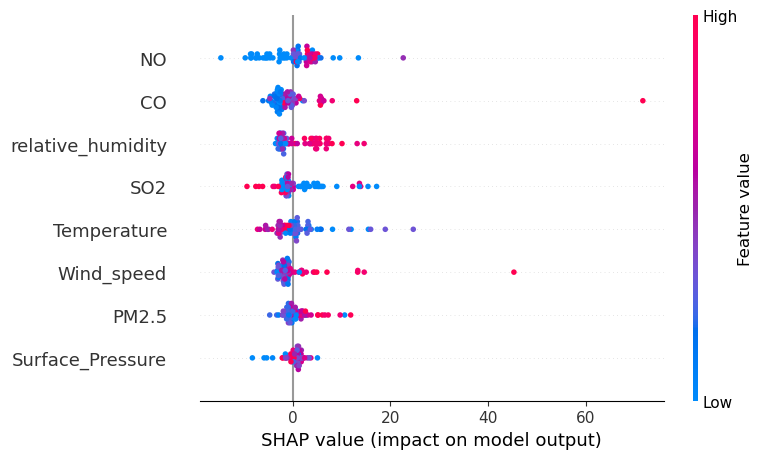

In [30]:
import shap

# Create a SHAP explainer for the best Gradient Boosting Regressor model
explainer = shap.Explainer(best_gbr, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Plot SHAP summary to show feature importance
shap.summary_plot(shap_values, X_test, feature_names=features)


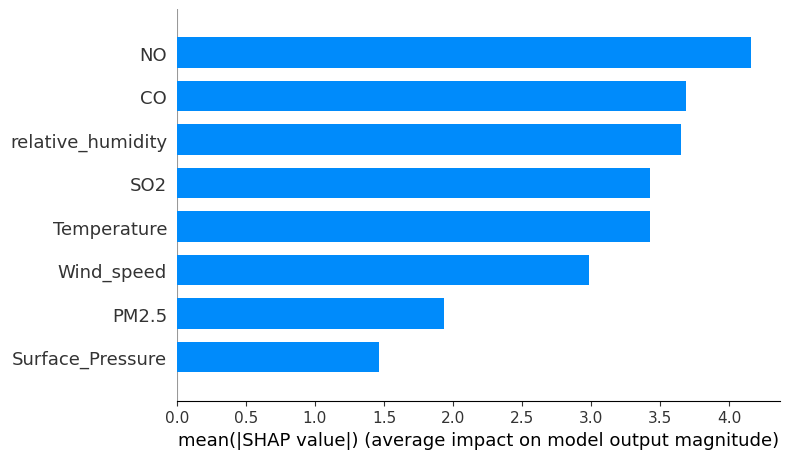

In [108]:
import shap

# Create a SHAP explainer for the best Gradient Boosting Regressor model
explainer = shap.Explainer(best_gbr, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Generate a bar chart for global feature importance
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type='bar')


# A(H3N2)

In [ ]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ensure you have imported train_test_split
from sklearn.model_selection import train_test_split

# Features and target
features = ['Temperature', 'Wind_speed', 'Surface_Pressure', 'NO', 'PM2.5', 'SO2', 'CO', 'relative_humidity']
target = 'A(H3N2)'

# Step 1: Prepare the data
X = ft2[features].values  # Feature matrix
y = ft2[target].values  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", grid_search.best_params_)

# Best estimator
best_gbr = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_gbr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print(f"Best Gradient Boosting Regressor - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


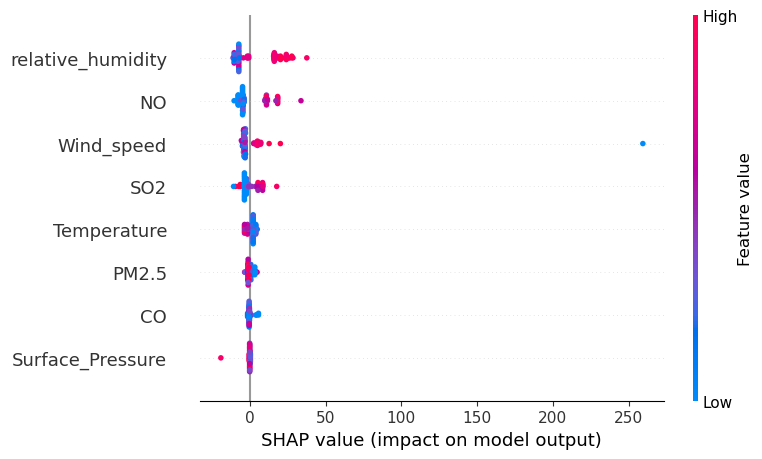

In [114]:
# Create a SHAP explainer for the best Gradient Boosting Regressor model
explainer = shap.Explainer(best_gbr, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Plot SHAP summary to show feature importance
shap.summary_plot(shap_values, X_test, feature_names=features)


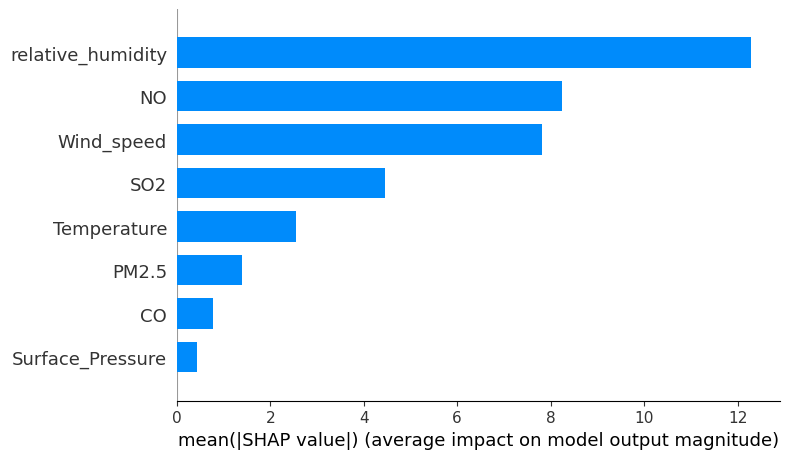

In [116]:
import shap

# Create a SHAP explainer for the best Gradient Boosting Regressor model
explainer = shap.Explainer(best_gbr, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Generate a bar chart for global feature importance
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type='bar')


# B

In [119]:
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# Ensure you have imported train_test_split
from sklearn.model_selection import train_test_split

# Features and target
features = ['Temperature', 'Wind_speed', 'Surface_Pressure', 'NO', 'PM2.5', 'SO2', 'CO', 'relative_humidity']
target = 'B'

# Step 1: Prepare the data
X = ft2[features].values  # Feature matrix
y = ft2[target].values  # Target variable

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Define the parameter grid for Gradient Boosting
param_grid = {
    'n_estimators': [100, 200, 300],
    'learning_rate': [0.01, 0.1, 0.2],
    'max_depth': [3, 5, 7]
}

# Initialize Gradient Boosting Regressor
gbr = GradientBoostingRegressor(random_state=42)

# Set up GridSearchCV
grid_search = GridSearchCV(estimator=gbr, param_grid=param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the model
grid_search.fit(X_train, y_train)

# Best hyperparameters
print("Best parameters:", grid_search.best_params_)

# Best estimator
best_gbr = grid_search.best_estimator_

# Make predictions on the test set using the best model
y_pred = best_gbr.predict(X_test)

# Calculate R-squared
r2 = r2_score(y_test, y_pred)

# Calculate MSE, MAE, and RMSE
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)

# Print the results
print(f"Best Gradient Boosting Regressor - R-squared: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"MAE: {mae:.4f}")
print(f"RMSE: {rmse:.4f}")


Best parameters: {'learning_rate': 0.2, 'max_depth': 3, 'n_estimators': 300}
Best Gradient Boosting Regressor - R-squared: 0.6902
MSE: 9983.2964
MAE: 48.3814
RMSE: 99.9164


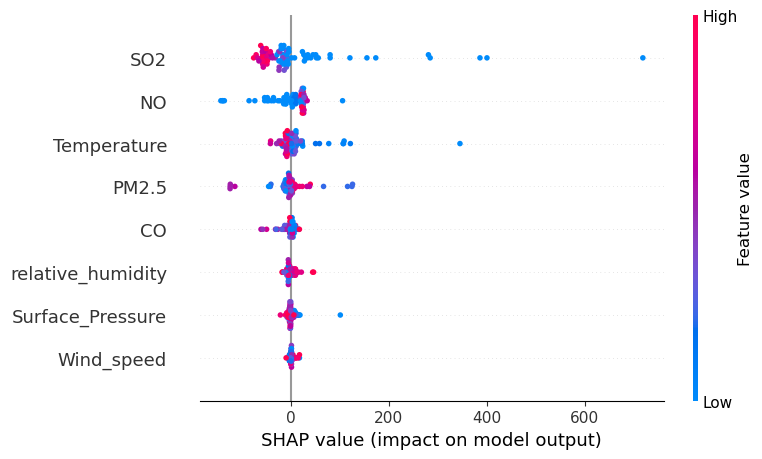

In [121]:
# Create a SHAP explainer for the best Gradient Boosting Regressor model
explainer = shap.Explainer(best_gbr, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Plot SHAP summary to show feature importance
shap.summary_plot(shap_values, X_test, feature_names=features)


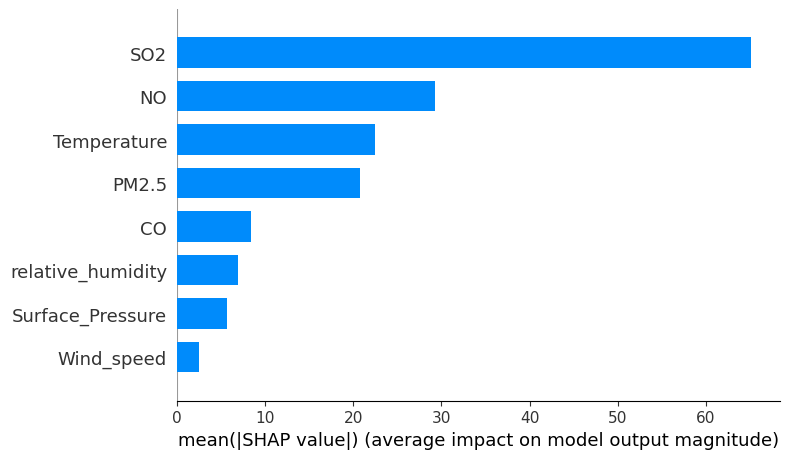

In [123]:
import shap

# Create a SHAP explainer for the best Gradient Boosting Regressor model
explainer = shap.Explainer(best_gbr, X_train)

# Calculate SHAP values for the test set
shap_values = explainer(X_test)

# Generate a bar chart for global feature importance
shap.summary_plot(shap_values, X_test, feature_names=features, plot_type='bar')
